In [1]:
from aub_htp import alpha_stable
from scipy.optimize import minimize
import numpy as np


def f(alpha, beta, shift, xmin=-100, xmax=100, bins=200):
    samples = alpha_stable.rvs(alpha, beta, size=500) + shift

    samples = samples[(samples >= xmin) & (samples <= xmax)]

    hist_density, bin_edges = np.histogram(
        samples,
        bins=bins,
        range=(xmin, xmax),
        density=True
    )
    x = (bin_edges[:-1] + bin_edges[1:]) / 2
    y = alpha_stable.pdf(x, alpha, beta)
    mse = np.mean((hist_density - y) ** 2)
    return mse

def optimal_shift(alpha, beta):
    return minimize(lambda shift: f(alpha, beta, shift), 0).x[0]


def generate_data(n_samples=100):
    a = np.linspace(0.01, 1.99, n_samples)
    b = np.linspace(-0.99, 0.99, n_samples)
    y = np.asarray([optimal_shift(a_, b_) for a_, b_ in zip(a, b)])

    X = np.stack([a, b], axis=1)
    return X.astype(np.float32), y.astype(np.float32)

X_train, y_train = generate_data()

/home/thinkito/Desktop/Research Assistant/AUB-HTP/aub_htp/random/alpha_stable_sampler.py:21: RuntimeWarning: overflow encountered in power
  weights = cumulative_exponential ** (-1.0 / alpha)
/home/thinkito/Desktop/Research Assistant/AUB-HTP/aub_htp/random/alpha_stable_sampler.py:21: RuntimeWarning: overflow encountered in power
  weights = cumulative_exponential ** (-1.0 / alpha)


In [2]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(hidden_layer_sizes=(64,64),
                     activation='relu',
                     max_iter=5000
                     )

model.fit(X_train, y_train)

,loss,'squared_error'
,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,5000
,shuffle,True


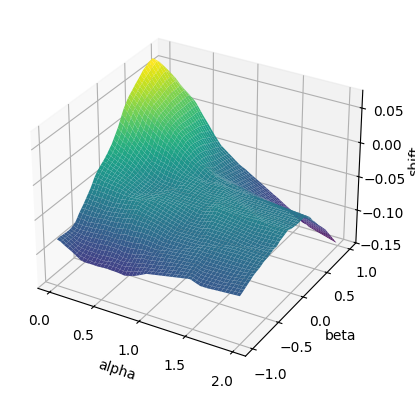

In [3]:
# Create grid
import matplotlib.pyplot as plt
x = np.linspace(min(X_train[:,0]), max(X_train[:,0]), 500)
y = np.linspace(min(X_train[:,1]), max(X_train[:,1]), 500)
X, Y = np.meshgrid(x, y)

# Define Z based on your model or function
Z = model.predict(np.c_[X.ravel(), Y.ravel()]).reshape(X.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')


ax.set_xlabel('alpha')
ax.set_ylabel('beta')
ax.set_zlabel('shift')

plt.show()